# 🏦 Loan Default Prediction using Naïve Bayes



## 🔁 Workflow

```
Load Data → EDA → Preprocessing → Train/Test Split →
Train Model → Evaluate → Visualize Results
```

##  Step 1: Import Libraries

In [26]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt



##  Step 2: Load the Dataset

In [27]:
df = pd.read_csv('loan_data (1).csv')
# df.shape
df.isnull().sum()
df.dropna(inplace = True)


##  Step 3: Exploratory Data Analysis (EDA)

<Axes: xlabel='loan_status', ylabel='count'>

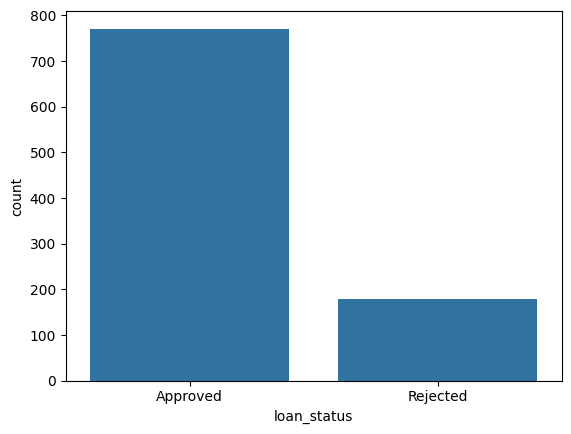

In [28]:
# Basic info
df.info
# Statistical summary
df.describe()
# Missing values
df.isnull().sum()
# Target variable distribution
df['loan_status'].value_counts()

# Correlation heatmap (numeric columns only)
sns.countplot(data = df, x ='loan_status')

## 🛠️ Step 4: Data Preprocessing

> **Why preprocessing?**  
> Naïve Bayes (GaussianNB) works with **numeric values only**.  
> We need to convert categorical columns (text) into numbers using **Label Encoding/ oneHot Encoding**.

In [29]:
# Make a copy so original data is safe
df_copy = df.copy()
df_copy=df_copy.drop('applicant_id',axis=1)
df_copy.head(2)

,age,annual_income,loan_amount,monthly_emi,credit_score,existing_loans,city,education,employment_type,has_property,loan_status
0,50,372619,246324,34598.0,572.0,0,Kolkata,Graduate,Salaried,0,Approved
1,36,512306,302698,31961.0,780.0,4,Delhi,Graduate,Salaried,1,Rejected


In [30]:
# Identify categorical columns
cat_col = df_copy.select_dtypes(include='object').columns.drop('loan_status')
cat_col

Index(['city', 'education', 'employment_type'], dtype='object')

In [31]:
# Label Encoding/ one hot encoding
df_copy = df.copy()
df_copy = pd.get_dummies(df_copy,
                         columns = cat_col,
                         dtype = int,
                         drop_first= True)
df_copy.head(2)
df_copy.shape



(950, 19)

In [32]:
df_copy=df_copy.drop('applicant_id',axis=1)


In [33]:
from sklearn.preprocessing import LabelEncoder
Le = LabelEncoder()
df_copy['loan_status'] = Le.fit_transform(df_copy['loan_status'])
df_copy['loan_status'].head()

,loan_status
0,0
1,1
2,0
3,0
4,0


In [34]:
X = df_copy.drop('loan_status', axis = 1)
y = df_copy['loan_status']


In [35]:
# Define Features (X) and Target (y)

## ✂️ Step 5: Train-Test Split

> We split the data into **80% training** and **20% testing**.  
> The model **learns from training data** and is **evaluated on test data** it has never seen.

In [36]:
# Train-Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [37]:
# Perform class imbalance
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state = 42)
X_train, y_train = smote.fit_resample(X_train, y_train)
X_train.shape,y_train.shape

((1240, 17), (1240,))

## 🤖 Step 6: Train the Naïve Bayes Model

> **GaussianNB** assumes features follow a **Normal (Gaussian) distribution**.  
> It calculates the **mean** and **variance** of each feature for each class.

In [40]:
# Initialize and Train the model
from sklearn.naive_bayes import GaussianNB
model = GaussianNB()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_pred_train = model.predict(X_train)

In [41]:
comapre=pd.DataFrame({'Actual':y_test,'Predicted':y_pred})
comapre.head(10)

,Actual,Predicted
210,0,0
977,0,0
726,0,1
836,1,0
918,0,0
607,0,1
865,0,1
972,0,0
517,1,1
184,0,1


## 📊 Step 7: Model Evaluation

In [45]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1 Score: {f1}')
print(f'Accuracy: {accuracy}')


Precision: 0.20353982300884957
Recall: 0.5897435897435898
F1 Score: 0.3026315789473684
Accuracy: 0.4421052631578947


<Axes: >

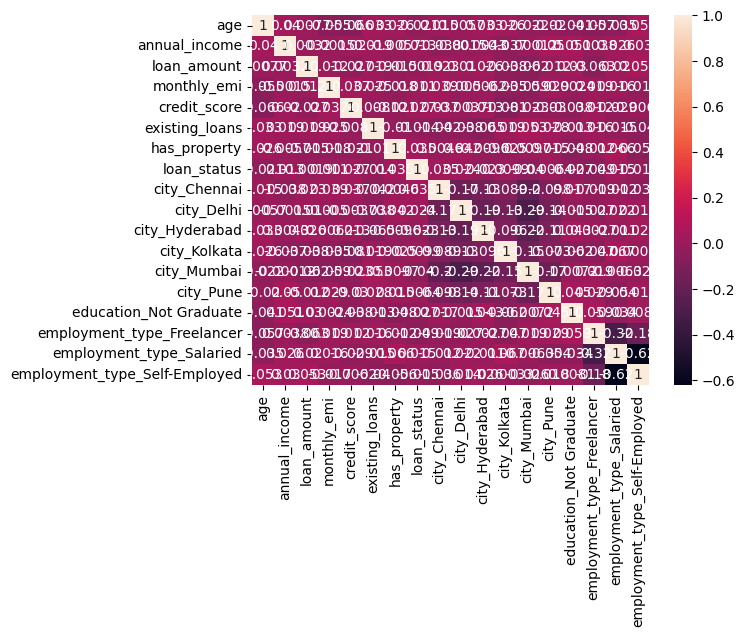

In [43]:
sns.heatmap(df_copy.corr(), annot = True)

## 🔮 Step 8: Predict for a New Loan Applicant

> Let's simulate a **real-world prediction** for a new applicant who has **not been seen by the model** before.

In [55]:
print(df['loan_status'])

0      Approved
1      Rejected
2      Approved
3      Approved
4      Approved
         ...   
994    Approved
995    Approved
996    Rejected
997    Approved
998    Approved
Name: loan_status, Length: 950, dtype: object


In [59]:
new_applicant = pd.DataFrame([{ # Wrap the dict in a list to create a single-row DataFrame
    'applicant_id':'IND2001',
    'age':25,
    'annual_income':2580000,
    'loan_amount':436000,
    'monthly_emi':5400,
    'credit_score':972.0,
    'existing_loans':1,
    'city':'Bhopal',
    'education':'Graduate',
    'employment_type':'Self Employed', # Corrected typo: 'self_employed' to 'Self Employed'
    'has_property':1,
    'loan_status':'Approved' # Corrected typo: 'Aproved' to 'Approved'
}])

In [60]:
# Drop 'applicant_id' and 'loan_status' from new_applicant for prediction
new_applicant_features = new_applicant.drop(['applicant_id', 'loan_status'], axis=1)

# Identify categorical columns in the new applicant data (excluding 'loan_status' which is already dropped)
cat_col_new_applicant = new_applicant_features.select_dtypes(include='object').columns

# Apply one-hot encoding to the new applicant data
new_applicant_encoded = pd.get_dummies(new_applicant_features,
                                       columns=cat_col_new_applicant,
                                       dtype=int,
                                       drop_first=True)

# Get the list of columns from the original training data X
# We'll use the columns from the original X, which was derived from df_copy after one-hot encoding.
# cat_col was defined as ['city', 'education', 'employment_type'] in crhVCfsmJnPk
# The one-hot encoding in 2SgaWN6_JtnM used drop_first=True.
# X was defined in ac_WjBkvMfgT as df_copy.drop('loan_status', axis = 1).

# Recreate the column names that X was trained on, considering drop_first=True
# The best way to ensure column alignment is to explicitly re-create the dummy columns
# using the same categories as seen in the training data, then align.

# Get all columns from X (the training features)
original_X_cols = X.columns

# Align columns - add missing columns (if any) and reindex
# First, ensure all original X columns are present in new_applicant_encoded, filling with 0 if not
for col in original_X_cols:
    if col not in new_applicant_encoded.columns:
        new_applicant_encoded[col] = 0

# Then, reorder the columns to match original X
new_applicant_aligned = new_applicant_encoded[original_X_cols]

new_applicant_aligned.head()

,age,annual_income,loan_amount,monthly_emi,credit_score,existing_loans,has_property,city_Chennai,city_Delhi,city_Hyderabad,city_Kolkata,city_Mumbai,city_Pune,education_Not Graduate,employment_type_Freelancer,employment_type_Salaried,employment_type_Self-Employed
0,25,2580000,436000,5400,972.0,1,1,0,0,0,0,0,0,0,0,0,0


In [61]:
# Make prediction for the new applicant
new_applicant_prediction_encoded = model.predict(new_applicant_aligned)

# Inverse transform the prediction to get original label (Approved/Rejected)
# Remember Le was fit on ['Approved', 'Rejected'] -> [0, 1] (or vice versa)
# Check the classes of Le
predicted_loan_status = Le.inverse_transform(new_applicant_prediction_encoded)

print(f"Predicted Loan Status for New Applicant: {predicted_loan_status[0]}")

Predicted Loan Status for New Applicant: Approved
